## Metrics aggregation
Load all metric runs from `results/new_object_placement/poster/*/metrics.json` and plot each metric across runs.

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option('display.max_columns', None)


In [2]:
base = Path('results/new_object_placement/poster')
run_dirs = sorted([p for p in base.iterdir() if p.is_dir()], key=lambda p: int(p.name))
records = []
for run in run_dirs:
    metrics_path = run / 'metrics.json'
    if not metrics_path.exists():
        print(f'Skipping {run} (no metrics.json)')
        continue
    with metrics_path.open() as f:
        data = json.load(f)
    data['run'] = run.name
    records.append(data)

if not records:
    raise RuntimeError('No metrics found.')

df = pd.DataFrame(records).set_index('run').sort_index(key=lambda idx: idx.astype(int))
df


Skipping results/new_object_placement/poster/4 (no metrics.json)


,z_mean_before,z_std_before,z_mean_after,z_std_after,z_mean_delta,depth_ratio,area_before,area_after,scale_applied,scale_observed,scale_error,scale_error_rel,fid,ssim,mask_iou,time_full_depth,time_object_prep,time_scene_masks,time_mpi_build,time_null_text,time_diffusion,time_iteration_total
run,,,,,,,,,,,,,,,,,,,,,,
0,61.534904,8.768065,165.034317,10.699545,103.499413,0.372861,2120.0,1078.0,3.000000,0.713085,0.340224,0.912468,9.648665,0.942791,0.505821,1.940141,10.548800,6.282493,0.039508,200.410552,104.338425,336.146986
1,112.519142,5.481406,105.339462,10.164406,-7.179680,1.068158,1776.0,2772.0,1.042735,1.249324,0.181167,0.169607,28.473253,0.888397,0.901348,1.196973,4.917781,5.652632,0.033528,204.870868,118.993209,347.024332
2,234.500809,10.684414,87.947113,33.749973,-146.553696,2.666384,8724.0,15504.0,0.538462,1.333104,1.333280,0.500033,57.369120,0.830494,0.720708,1.698104,5.284087,5.548829,0.035205,212.534989,107.652337,343.585583
3,40.656544,1.771820,48.281158,11.845377,7.624615,0.842079,14127.0,9724.0,1.604651,0.829655,0.012424,0.014754,14.203825,0.928620,0.326972,1.650207,5.138953,6.027635,0.033358,215.011881,126.360796,364.819574
5,50.180336,3.866675,44.846321,9.803594,-5.334015,1.118940,2024.0,7750.0,0.658228,1.956796,0.837856,0.748795,12.686216,0.889305,NaN,1.944832,8.666013,5.485916,0.040714,216.802817,137.880483,383.074829
6,21.403839,1.068814,88.067307,7.142810,66.663467,0.243040,2917.0,2184.0,0.224490,0.865283,0.622243,2.560255,2.720930,0.857968,0.764093,1.591613,5.551885,5.591446,0.033525,200.011711,138.033628,361.631045
7,26.821598,1.870469,39.371735,16.692911,12.550137,0.681240,4019.0,33166.0,0.421875,2.872682,2.191442,3.216843,12.869824,0.736065,0.540846,1.680362,6.046633,6.064169,0.033961,199.782991,136.733050,360.322575
8,124.917534,1.804165,64.914429,12.416921,-60.003105,1.924342,10053.0,6708.0,1.482353,0.816862,1.107480,0.575511,17.884780,0.905638,0.820080,1.577804,5.970633,5.611220,0.032488,220.976242,136.224826,380.346348
9,133.826248,9.130283,108.144417,23.740210,-25.681831,1.237477,7977.0,16002.0,0.918919,1.416339,0.178862,0.144538,12.620852,0.928648,0.248027,1.675935,5.129629,5.930751,0.032770,213.691536,136.285008,372.333510


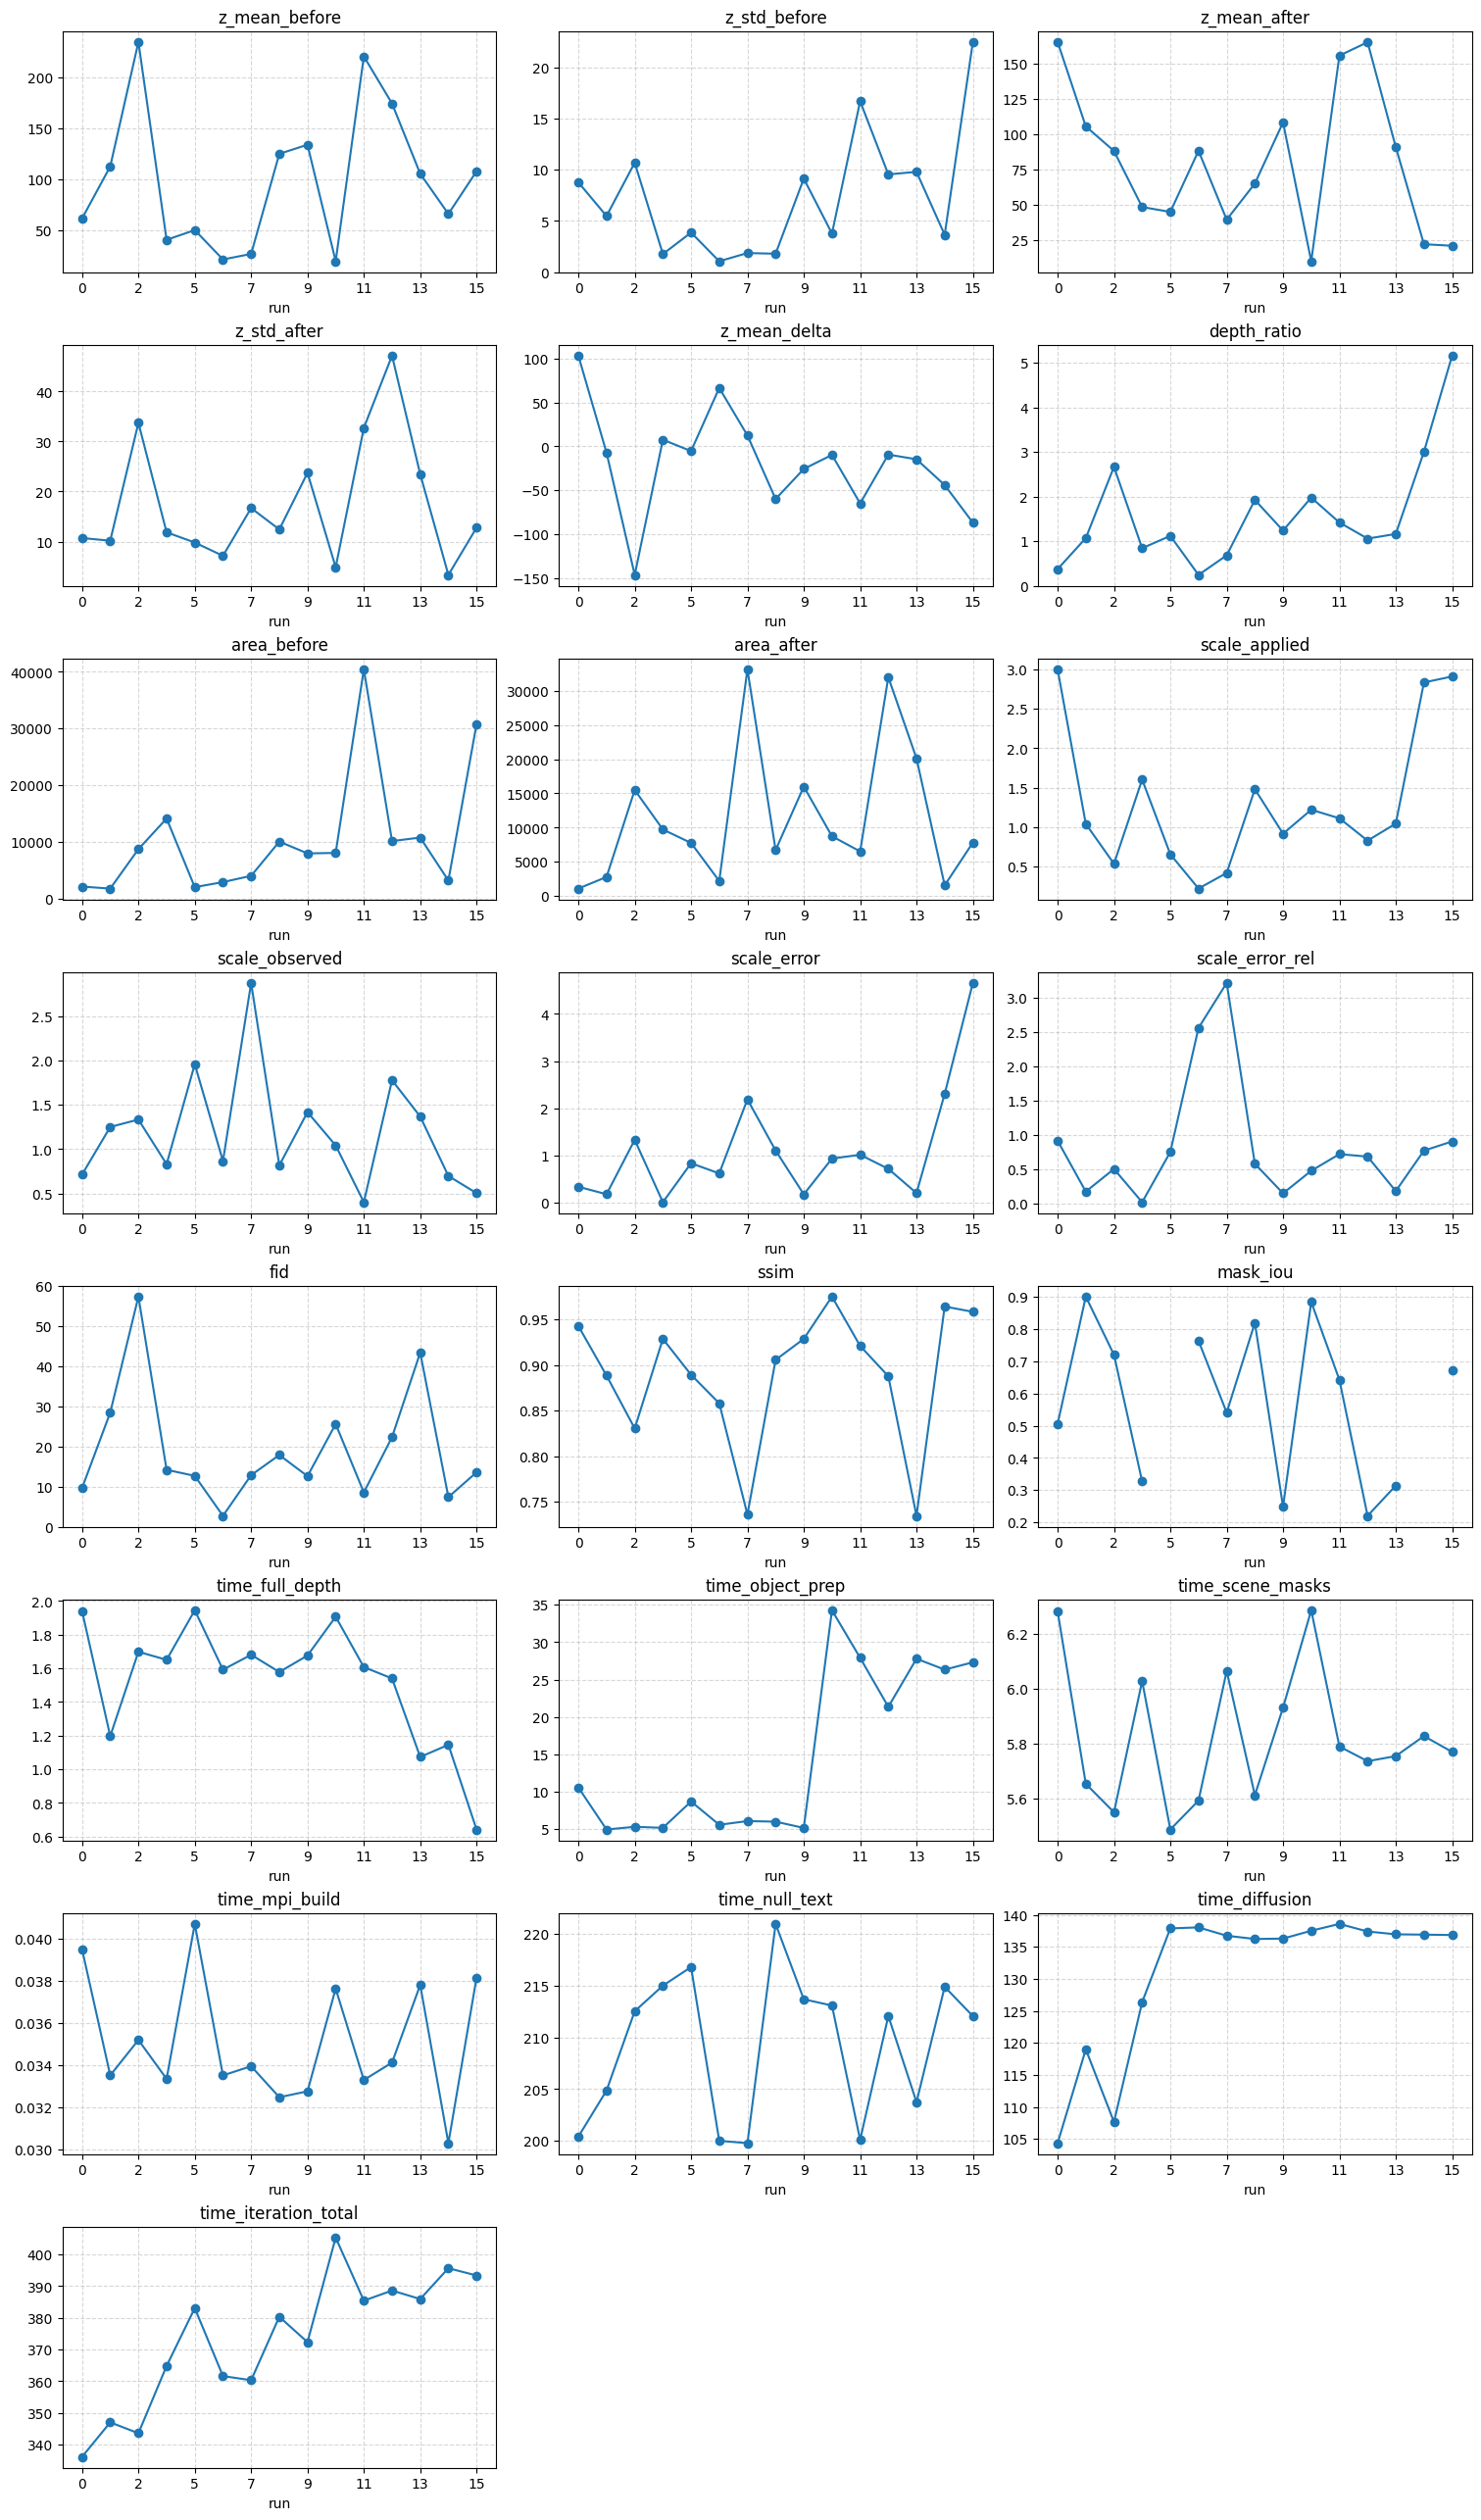

In [3]:
metrics = df.columns.tolist()
n_cols = 3
n_rows = math.ceil(len(metrics) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, metric in zip(axes, metrics):
    series = df[metric].astype(float)
    series.plot(ax=ax, marker='o')
    ax.set_title(metric)
    ax.set_xlabel('run')
    ax.grid(True, linestyle='--', alpha=0.5)

for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.show()
